<a href="https://www.kaggle.com/code/zahidmughal2343/games-sales-random-forest-regressor?scriptVersionId=241391535" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/video-games-sale/video games sales.csv


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load The Data

In [3]:
df = pd.read_csv("/kaggle/input/video-games-sale/video games sales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# Shape of Data

In [4]:
df.shape

(16598, 11)

# Information The Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


# Check The Missing Values

In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

# Handle Missing Values

In [8]:
median_year = df['Year'].median()
df['Year'].fillna(median_year, inplace=True)
df['Publisher'].fillna('Unknown', inplace=True)
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


# Exploratory Data Analysis (EDA)

### Overview of Categorical Features

In [9]:
print("Unique Platforms:", df['Platform'].nunique())
print("Unique Genres:", df['Genre'].nunique())
print("Unique Publishers:", df['Publisher'].nunique())

Unique Platforms: 31
Unique Genres: 12
Unique Publishers: 578


### Top 10 Video Games by Global Sales

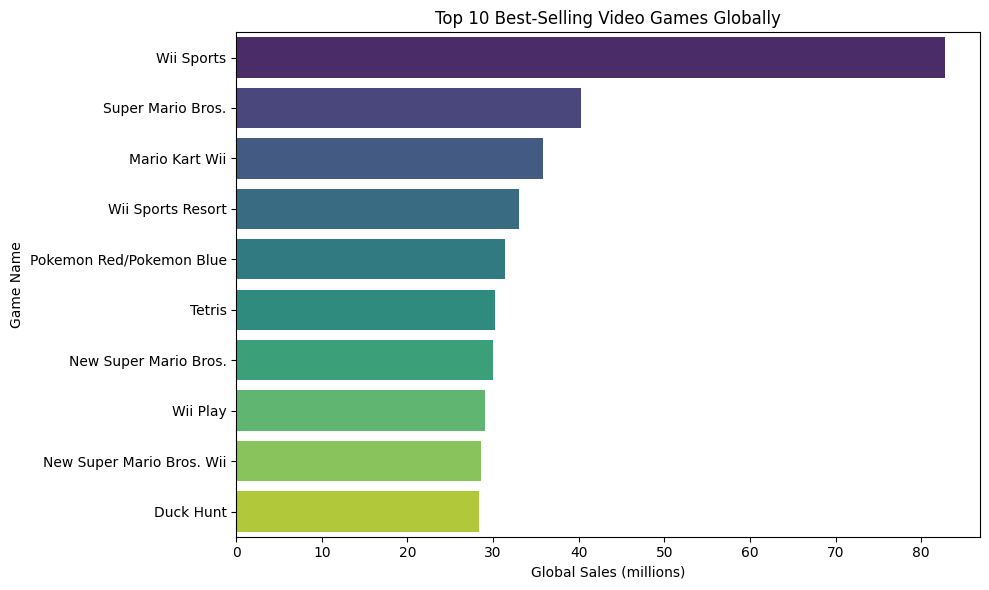

In [10]:
top_games = df[['Name', 'Global_Sales']].sort_values(by='Global_Sales', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_games, x='Global_Sales', y='Name', palette='viridis')
plt.title('Top 10 Best-Selling Video Games Globally')
plt.xlabel('Global Sales (millions)')
plt.ylabel('Game Name')
plt.tight_layout()
plt.show()

### Sales Distribution by Genre

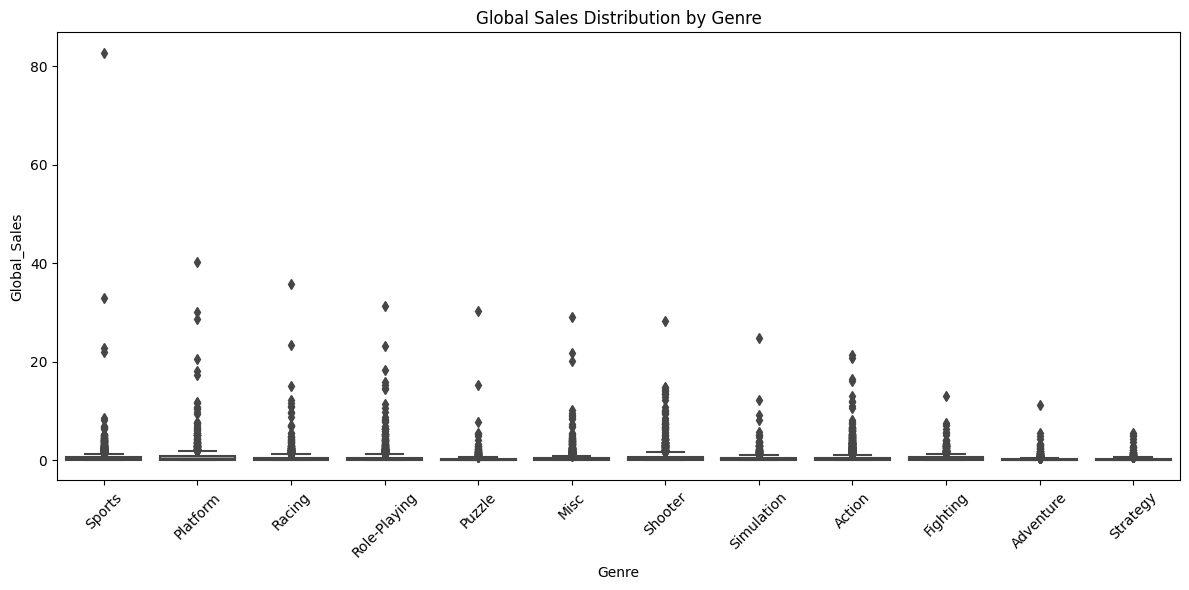

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Genre', y='Global_Sales')
plt.title('Global Sales Distribution by Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Global Sales by Platform

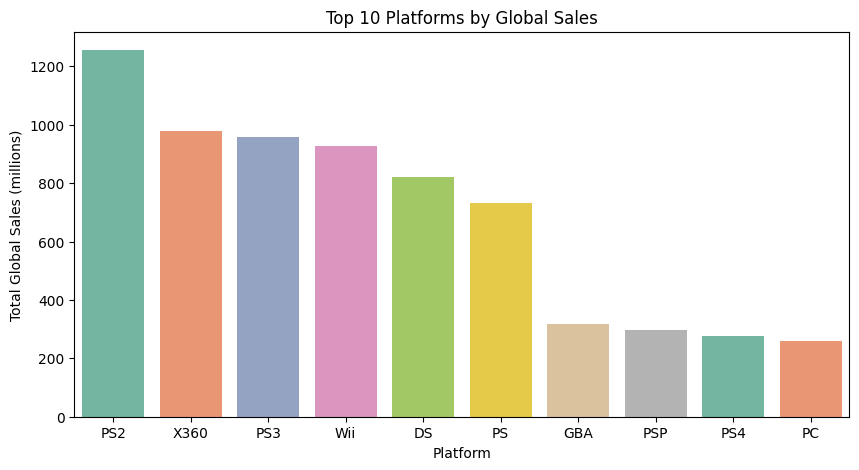

In [12]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=platform_sales.index, y=platform_sales.values, palette='Set2')
plt.title('Top 10 Platforms by Global Sales')
plt.xlabel('Platform')
plt.ylabel('Total Global Sales (millions)')
plt.show()

### Sales Trends Over the Years

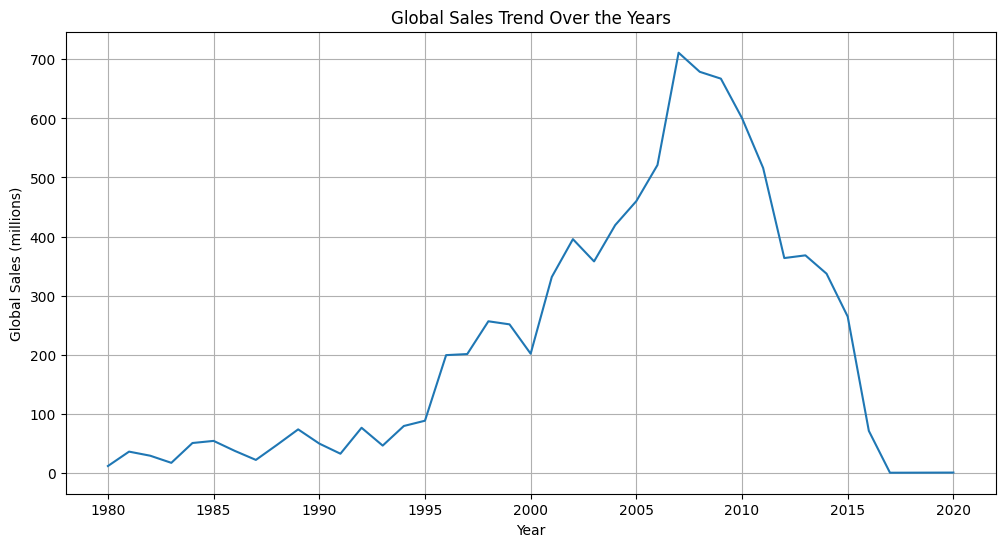

In [13]:
sales_by_year = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values)
plt.title('Global Sales Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (millions)')
plt.grid(True)
plt.show()

### Regional Sales Comparison

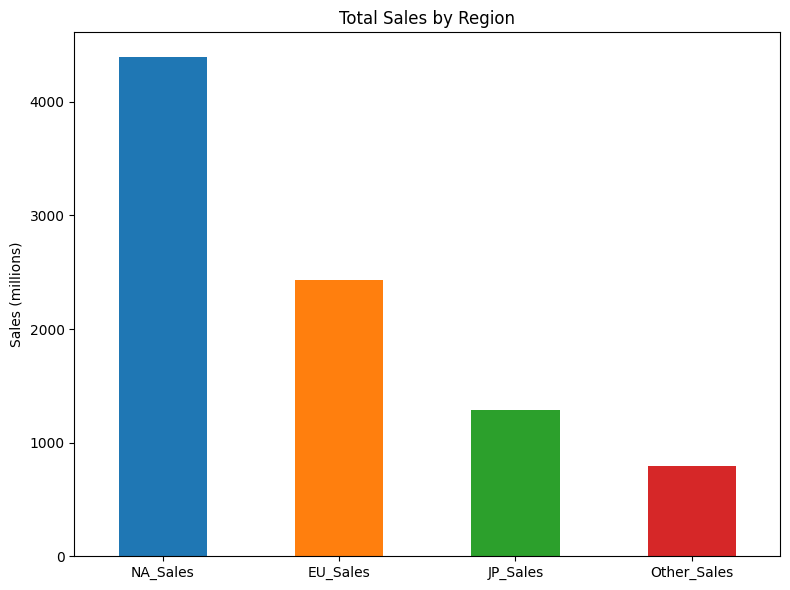

In [14]:
region_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(8, 6))
region_totals.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Total Sales by Region')
plt.ylabel('Sales (millions)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Global Sales by Genre

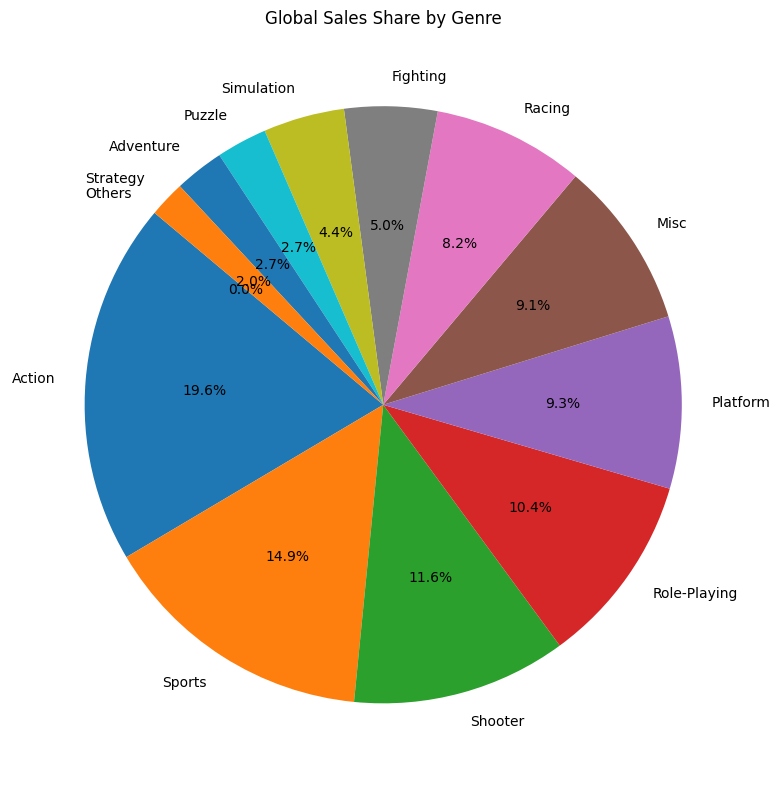

In [15]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

# Select top genres that together cover most of the sales
top_genres = genre_sales[genre_sales > 100]
others = genre_sales[genre_sales <= 100].sum()

# Combine small genres into 'Others'
genre_sales_cleaned = top_genres.copy()
genre_sales_cleaned['Others'] = others

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(genre_sales_cleaned, labels=genre_sales_cleaned.index, autopct='%1.1f%%', startangle=140)
plt.title('Global Sales Share by Genre')
plt.tight_layout()
plt.show()

# Feature Engineering and Preprocessing

 ### Convert Year to Integer

In [16]:
df['Year'] = df['Year'].astype(int)

### Create a New Feature: Total Regional Sales

In [17]:
df['Total_Regional_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']

difference = (df['Global_Sales'] - df['Total_Regional_Sales']).abs().sum()
print("Total difference between Global and Regional Sales (should be small):", difference)

Total difference between Global and Regional Sales (should be small): 45.21000000000028


### Encoding Categorical Features

In [18]:
# Drop Name (not a useful predictor)
df.drop('Name', axis=1, inplace=True)

# Apply Label Encoding to categorical columns
label_encoders = {}

for column in ['Platform', 'Genre', 'Publisher']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

### Feature & Target Selection

In [19]:
X = df.drop(['Global_Sales', 'Total_Regional_Sales', 'Rank'], axis=1)
y = df['Global_Sales']

### Train-Test Split

In [20]:
# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training & Evaluation

 ### Train the Model

In [21]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Make Predictions

In [22]:
# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate the Model

In [23]:
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f" R² Score: {r2:.4f}")

RMSE (Root Mean Squared Error): 0.8626
 R² Score: 0.8229


### Feature Importance 

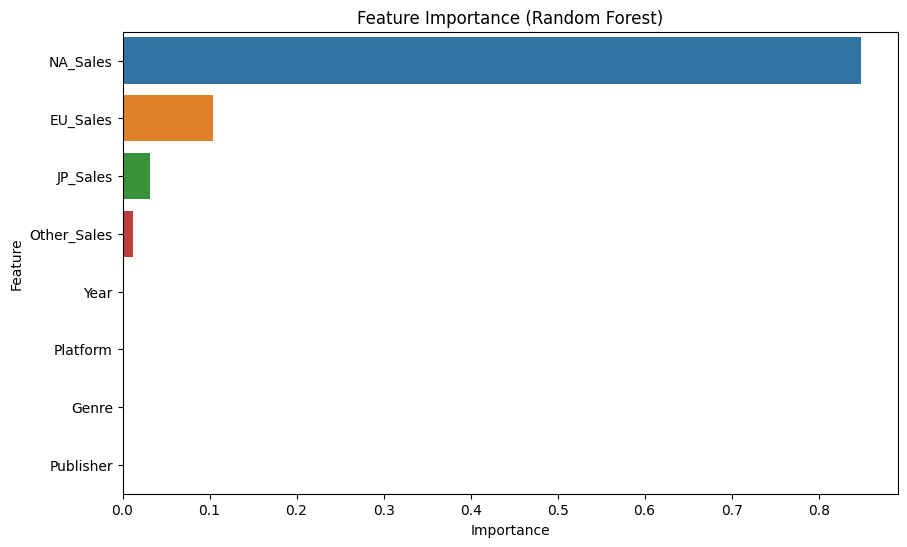

In [24]:
importances = rf_model.feature_importances_
features = X.columns
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title('Feature Importance (Random Forest)')
plt.show()

# Final Predictions

In [25]:
results = pd.DataFrame({'Actual_Sales': y_test.values,'Predicted_Sales': y_pred})
results.head(10)

,Actual_Sales,Predicted_Sales
0,0.15,0.150100
1,0.40,0.397800
2,0.02,0.023823
3,0.03,0.020900
4,0.36,0.364000
5,2.24,2.152800
6,0.39,0.399400
7,0.65,0.641700
8,0.21,0.212500
9,0.44,0.440000


 # Predictions vs Actual

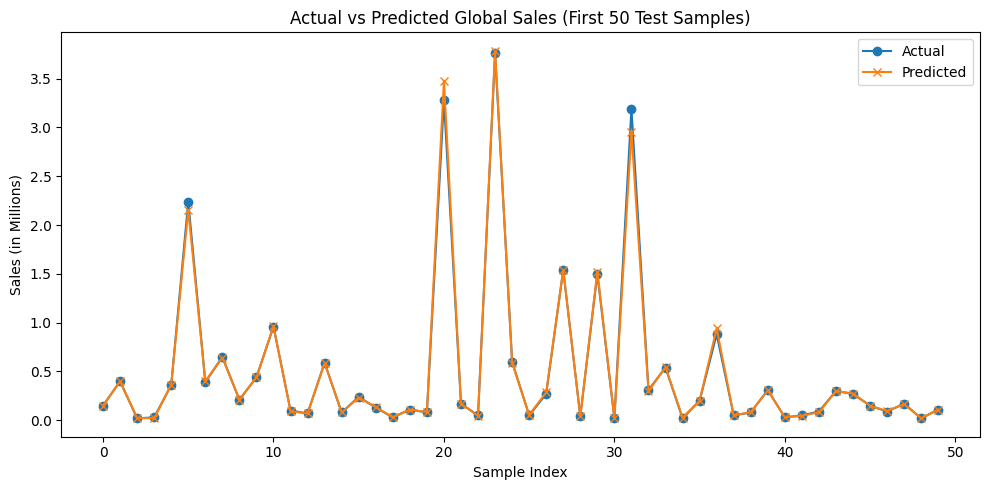

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(results['Actual_Sales'].values[:50], label='Actual', marker='o')
plt.plot(results['Predicted_Sales'].values[:50], label='Predicted', marker='x')
plt.title('Actual vs Predicted Global Sales (First 50 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Sales (in Millions)')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

In this project,Analyzed video game sales data to predict Global Sales using features like platform, genre, and regional sales. After data cleaning, visualization, and feature engineering, we trained a Random Forest Regressor which performed well with a good R² score. The model also helped identify key factors influencing global sales, such as NA_Sales and Platform. This workflow shows how machine learning can effectively support business insights in the gaming industry.

### Thanks To Visit My Notebook